Background:

We are one of the fastest growing startups in the logistics and delivery domain. We work with several partners and make on-demand delivery to our customers. From operational standpoint we have been facing several different challenges and everyday we are trying to address these challenges.

We thrive on making our customers happy. As a growing startup, with a global expansion strategy we know that we need to make our customers happy and the only way to do that is to measure how happy each customer is. If we can predict what makes our customers happy or unhappy, we can then take necessary actions.

Getting feedback from customers is not easy either, but we do our best to get constant feedback from our customers. This is a crucial function to improve our operations across all levels.

We recently did a survey to a select customer cohort. You are presented with a subset of this data. We will be using the remaining data as a private test set.

Y = target attribute (Y) with values indicating 0 (unhappy) and 1 (happy) customers

X1 = my order was delivered on time

X2 = contents of my order was as I expected

X3 = I ordered everything I wanted to order

X4 = I paid a good price for my order

X5 = I am satisfied with my courier

X6 = the app makes ordering easy for me

Attributes X1 to X6 indicate the responses for each question and have values from 1 to 5 where the smaller number indicates less and the higher number indicates more towards the answer.


# Exploratory Analysis

In [2]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE, RFECV
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline


In [3]:
# Load data
data = pd.read_csv("ACME-HappinessSurvey2020.csv")


In [4]:
# Rename columns
data.columns = ['customer_happiness', 'delivery_timeliness','order_accuracy','product_availability',
              'price_value_perception','courier_service_rating', 'app_usability']


### 1. Initial Data Inspection

In [5]:
# View the first few rows of the data
data.head()

,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
0,0,3,3,3,4,2,4
1,0,3,2,3,5,4,3
2,1,5,3,3,3,3,5
3,0,5,4,3,3,3,5
4,0,5,4,3,3,3,5


In [6]:
# Check the data types and missing values 
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   customer_happiness      126 non-null    int64
 1   delivery_timeliness     126 non-null    int64
 2   order_accuracy          126 non-null    int64
 3   product_availability    126 non-null    int64
 4   price_value_perception  126 non-null    int64
 5   courier_service_rating  126 non-null    int64
 6   app_usability           126 non-null    int64
dtypes: int64(7)
memory usage: 7.0 KB


In [7]:
# Get summary statistics for numerical columns
data.describe()


,customer_happiness,delivery_timeliness,order_accuracy,product_availability,price_value_perception,courier_service_rating,app_usability
count,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000,126.000000
mean,0.547619,4.333333,2.531746,3.309524,3.746032,3.650794,4.253968
std,0.499714,0.800000,1.114892,1.023440,0.875776,1.147641,0.809311
min,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,4.000000,2.000000,3.000000,3.000000,3.000000,4.000000
50%,1.000000,5.000000,3.000000,3.000000,4.000000,4.000000,4.000000
75%,1.000000,5.000000,3.000000,4.000000,4.000000,4.000000,5.000000
max,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [8]:
# Class balance
print("Target distribution:")
print(data['customer_happiness'].value_counts(normalize=True).round(2))


Target distribution:
customer_happiness
1    0.55
0    0.45
Name: proportion, dtype: float64


Data Quality & Readiness Assessment
- High Integrity: Dataset is complete (127 records) with no missing values, ensuring reliable analysis.
- Balanced Target: Customer satisfaction is evenly split (55/45), preventing model bias and ensuring fair predictions for both happy and unhappy customers.

### 2. Univariate and Bivariate Analysis

#### 2.1 Distribution by Class Plot

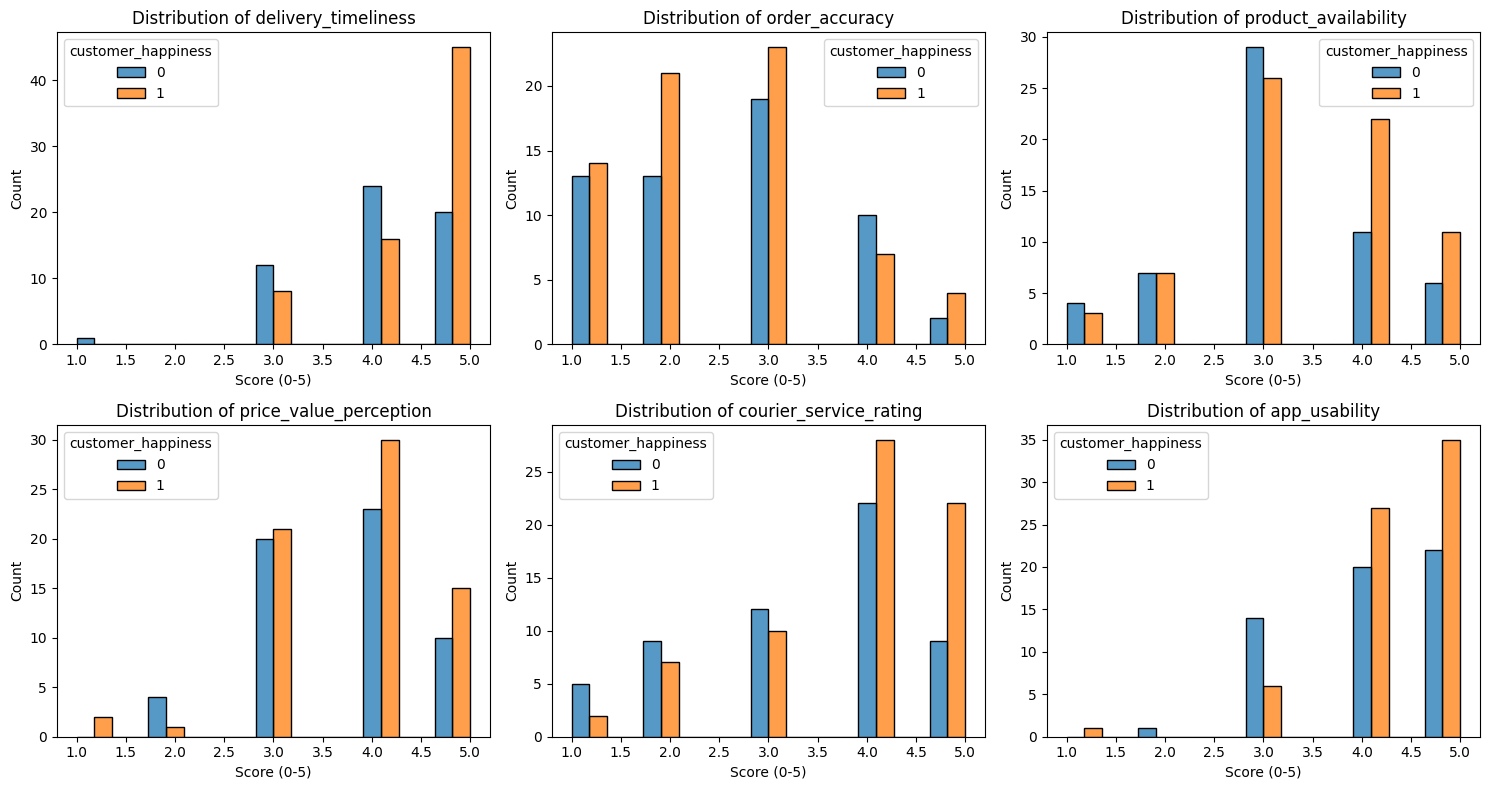

In [9]:
# Distribution of each feature by class
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for idx, feature in enumerate(data.drop('customer_happiness', axis=1).columns):
    sns.histplot(
        data=data, 
        x=feature, 
        hue='customer_happiness', 
        ax=axes[idx],
        multiple='dodge',
    )
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].set_xlabel('Score (0-5)')

plt.tight_layout()
plt.show()

These charts reveal which factors truly drive customer happiness. When we see a large difference between happy and unhappy customers at high satisfaction scores, that factor is a key driver of overall satisfaction.

Delivery timeliness shows the strongest pattern: at the highest score (5/5), happy customers far outnumber unhappy ones, making it the most influential factor. Courier service rating, product availability, price perception, and app usability also show clear gaps at scores of 4 and above, confirming their impact.

In contrast, order accuracy shows minimal difference between happy and unhappy customers, suggesting it has less influence on overall satisfaction than the other factors. 

#### 2.2 Correlation Heatmap
A correlation heatmap is used below to confirm and further filter the features that impact the customer satifaction.

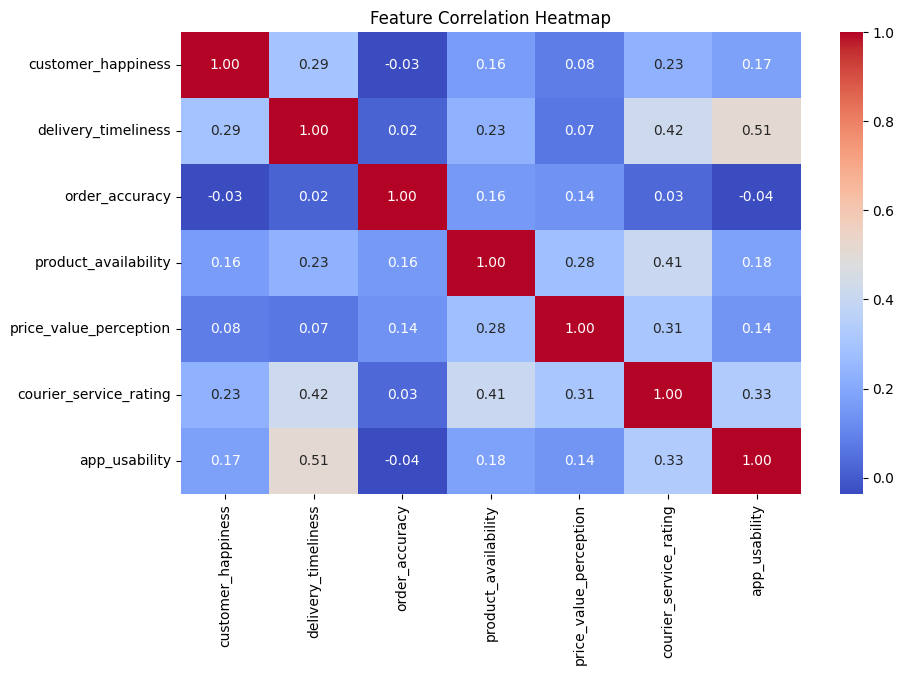

In [10]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
# Use Spearman correlation for ordinal data
sns.heatmap(data.corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

The heatmap shows the relationships between each feature with the customer happiness. 
- Delivery Timeliness and Courier Service have the strongest positive relationship with customer happiness. This confirms our earlier visual findings that logistics performance is critical.

- Order accuracy has correlation of negative 0.03 with the customer happiness, showing negligible impact on the customer happiness. This suggests order accuracy is a baseline expectation — likely because most orders are accurate, so it's not a varying factor that explains differences in satisfaction. 


#### 2.3 Validating the Results: Mean difference, T-test and Mann-Whitney U Test

The mean difference comparison, T-test and Mann-Whitney U Test were used to further evaluate the importance of features on the customer happiness score.

- Mean difference of feature score between happy vs. unhappy customers gives quick feature ranking of the features.
- T-test tests whether the mean difference between happy vs. unhappy customers for a feature is statistically significant.
- Mann-Whitney U Test was used because all data are ordinal and non-normal. 

In [11]:
means = data.groupby('customer_happiness').mean().T
means.columns = ['Unhappy (mean)', 'Happy (mean)']
means['Difference'] = means['Happy (mean)'] - means['Unhappy (mean)']
means = means.sort_values('Difference', ascending=False)
print("=== MEAN COMPARISON: Feature Predictive Power ===")
print(means.round(2))

=== MEAN COMPARISON: Feature Predictive Power ===
                        Unhappy (mean)  Happy (mean)  Difference
courier_service_rating            3.37          3.88        0.52
delivery_timeliness               4.09          4.54        0.45
product_availability              3.14          3.45        0.31
app_usability                     4.11          4.38        0.27
price_value_perception            3.68          3.80        0.11
order_accuracy                    2.56          2.51       -0.05


In [12]:
from scipy.stats import ttest_ind, mannwhitneyu

happy = data[data['customer_happiness'] == 1]
unhappy = data[data['customer_happiness'] == 0]

results = []

for col in data.drop('customer_happiness', axis=1).columns:
    # T-test (parametric)
    # Not applicable: Data is ordinal and may not be normally distributed, but we include it for reference
    # When data is continuous and normally distributed, t-test is appropriate. Here we use Welch's t-test which does not assume equal variances.
    t_stat, p_ttest = ttest_ind(happy[col], unhappy[col], equal_var=False)  # Welch's t-test
    
    # Mann-Whitney U (non-parametric)
    u_stat, p_mwu = mannwhitneyu(happy[col], unhappy[col], alternative='two-sided')
    
    results.append({
        'feature': col,
        'mean_happy': happy[col].mean().round(2),
        'mean_unhappy': unhappy[col].mean().round(2),
        'mean_diff': (happy[col].mean() - unhappy[col].mean()).round(2),
        'p_ttest': p_ttest.round(4),
        'p_mwu': p_mwu.round(4),
        'significant': p_mwu < 0.05  # Using Mann-Whitney U for decision
    })

results_df = pd.DataFrame(results).sort_values('mean_diff', ascending=False)
print("=== STATISTICAL SIGNIFICANCE OF FEATURE DIFFERENCES ===")
print(results_df.to_string(index=False))

=== STATISTICAL SIGNIFICANCE OF FEATURE DIFFERENCES ===
               feature  mean_happy  mean_unhappy  mean_diff  p_ttest  p_mwu  significant
courier_service_rating        3.88          3.37       0.52   0.0125 0.0111         True
   delivery_timeliness        4.54          4.09       0.45   0.0019 0.0011         True
  product_availability        3.45          3.14       0.31   0.0914 0.0702        False
         app_usability        4.38          4.11       0.27   0.0629 0.0519        False
price_value_perception        3.80          3.68       0.11   0.4711 0.3642        False
        order_accuracy        2.51          2.56      -0.05   0.7878 0.7032        False


Statistical testing shows how significant are the factors impacting the customer happiness and it confirms again that the strongest primary drivers for it is courier service rating and delivery timeliness.

#### 3. Model Evaluation

This section evaluates the models to predict the customer happiness score with and without feature selection. 

In [13]:
# Prepare data for modeling
# Extract features and target variable
X = data.drop(columns=['customer_happiness'])
y = data['customer_happiness']
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)


In [14]:
# Models to evaluate
models = {
    'Logistic Regression': LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=2, min_samples_leaf=10,class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(max_depth=3, n_estimators=100,class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(max_depth=3, n_estimators=100, learning_rate=0.1, random_state=42, scale_pos_weight=1)
}

In [15]:
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    results.append(
        {"Model Name": name, 
         "F1 Score with Test Data": classification_report(y_test, y_pred, output_dict=True)['weighted avg']['f1-score'],
         "Accuracy with Test Data": classification_report(y_test, y_pred, output_dict=True)['accuracy']
         }
        )
results_df = pd.DataFrame(results).sort_values('Accuracy with Test Data', ascending=False)
print("=== MODEL PERFORMANCE COMPARISON ===")
print(results_df.to_string(index=False))
    

=== MODEL PERFORMANCE COMPARISON ===
         Model Name  F1 Score with Test Data  Accuracy with Test Data
      Random Forest                 0.810223                  0.81250
Logistic Regression                 0.705329                  0.71875
      Decision Tree                 0.677579                  0.68750
            XGBoost                 0.612500                  0.62500


From the table above, the RandomForestClassifier has the highest accuracy and f1 score with the test data. Therefore, further feature selection will be implemented with this model to further improve the accuracy. 

3.1 XGBoost Fine - tunning

Trying xgboost with hyperparameter tuning as it is often a strong performer for tabular data.

In [17]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
xgb = XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight)

xgb_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],  
    "learning_rate": [0.1, 0.2, 0.3],
    "min_child_weight": [5, 10],

}

xgb_grid = GridSearchCV(
    xgb,
    xgb_param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
y_pred_xgb = xgb_grid.predict(X_test)

print(f"Best parameters: {xgb_grid.best_params_}")
print(f"Best cross-validation accuracy: {xgb_grid.best_score_:.2%}")
print(f"Test F1 score: {f1_score(y_test, y_pred_xgb):.2%}")
print(f"Test accuracy: {xgb_grid.score(X_test, y_test):.2%}")

Best parameters: {'learning_rate': 0.2, 'max_depth': 2, 'min_child_weight': 5, 'n_estimators': 200}
Best cross-validation accuracy: 54.39%
Test F1 score: 78.95%
Test accuracy: 75.00%


XGBoost has higher accuracy after hyperparameter fine-tunning, but it's still lower than the acurracy of Random Forest Classifier before any feature selection or fine-tunning. 

##### 3.2 Random Forest Fine-tunning

Random Forest Feature Ranking

In [18]:
rf = RandomForestClassifier(max_depth=3, n_estimators=100,class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
importances = rf.feature_importances_
perm_result= permutation_importance(
    rf, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Gini Importance': importances,
    'Permutation Importance': perm_result.importances_mean})
print("=== FEATURE IMPORTANCE FROM RANDOM FOREST ===")
print(feature_importance_df.sort_values('Gini Importance', ascending=False).to_string(index=False))



=== FEATURE IMPORTANCE FROM RANDOM FOREST ===
               Feature  Gini Importance  Permutation Importance
courier_service_rating         0.194315                0.100000
price_value_perception         0.181840                0.012500
  product_availability         0.170107                0.056250
   delivery_timeliness         0.160465                0.153125
        order_accuracy         0.152155                0.040625
         app_usability         0.141118                0.000000


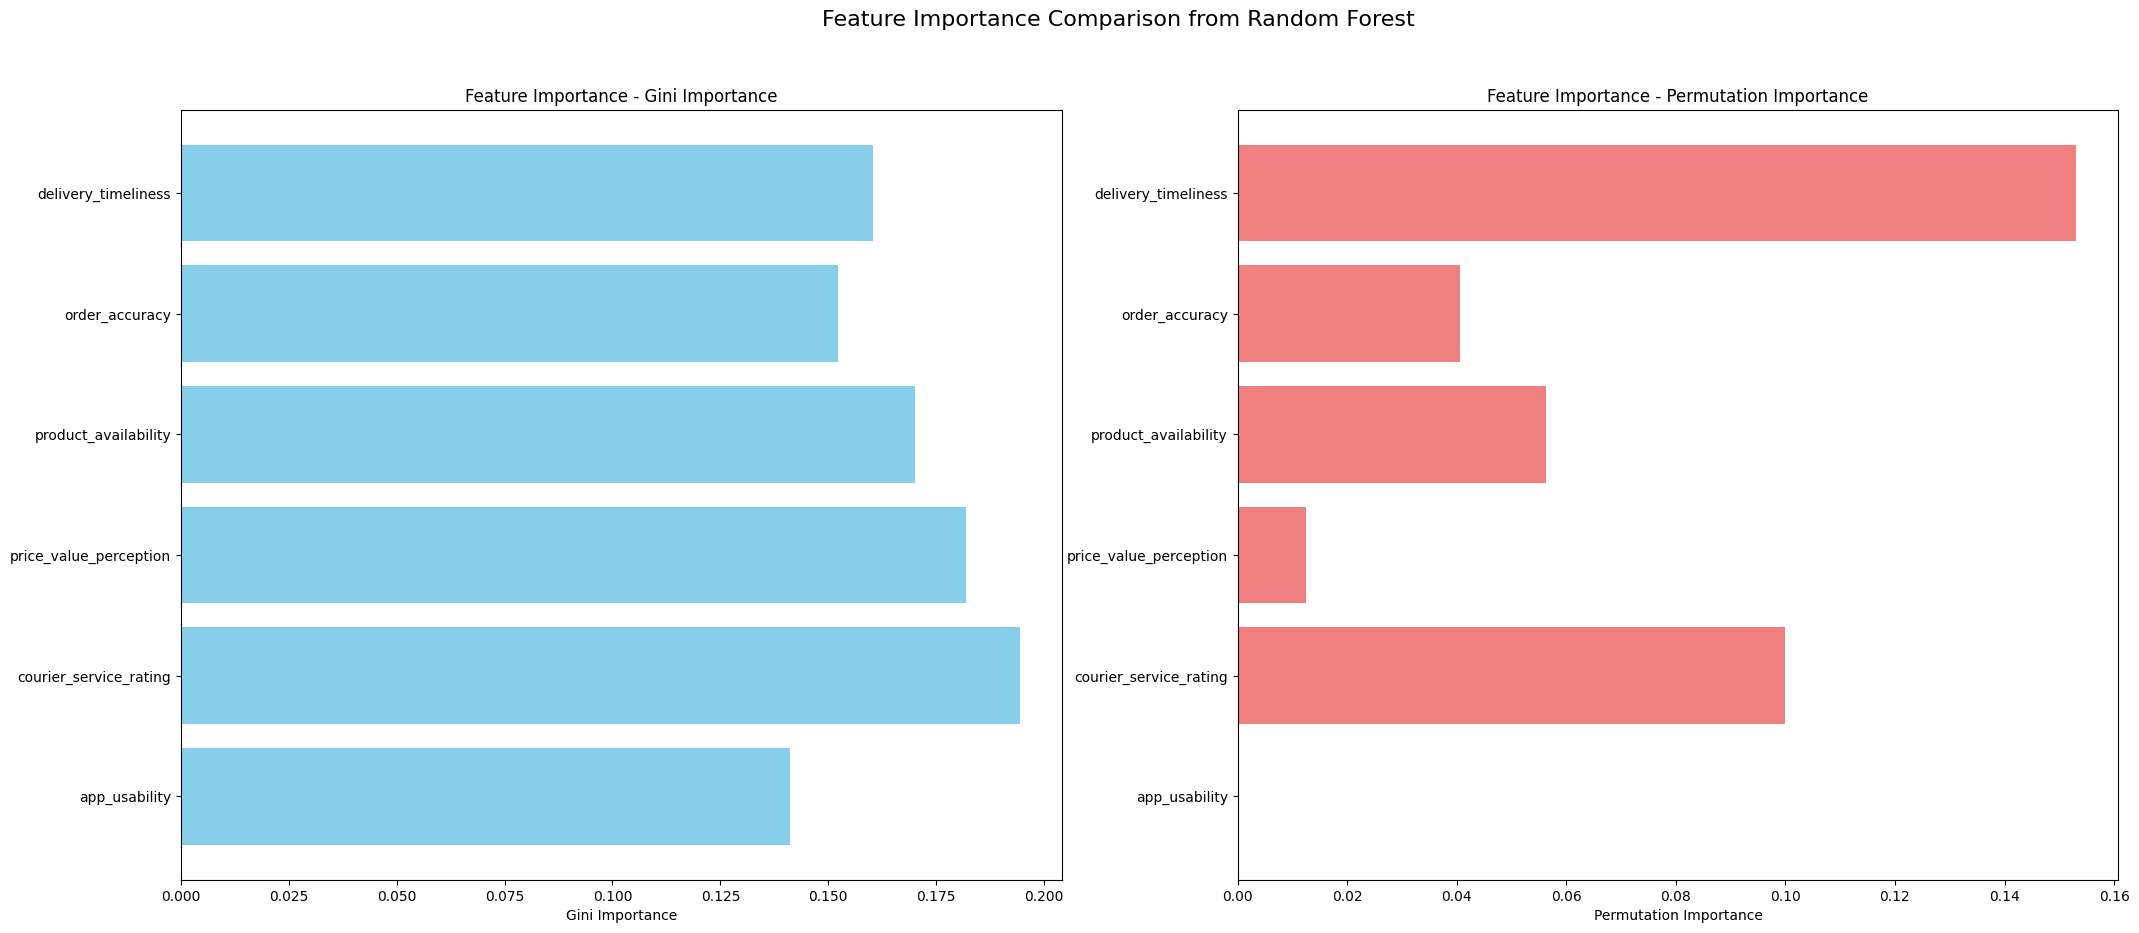

In [ ]:
# Add plots for feature importance comparison
fig, ax = plt.subplots(1,2, figsize=(25, 10))

ax[0].barh(X.columns, importances, color='skyblue')
ax[0].set_xlabel('Gini Importance')
ax[0].set_title('Feature Importance - Gini Importance')
ax[0].invert_yaxis()

ax[1].barh(X.columns, feature_importance_df['Permutation Importance'], color='lightcoral')
ax[1].set_xlabel('Permutation Importance')
ax[1].set_title('Feature Importance - Permutation Importance')
ax[1].invert_yaxis()

fig.suptitle('Feature Importance Comparison from Random Forest Model', fontsize=16)
plt.show()

Feature importance ranking for Random Forest Classifier shows that delivery timeliness and courier service rating remains the two strongest factors impacting the customer happinesses. 

Random Forest Feature Selection

In [20]:
# Using RFECV to select optimal features
# Setting min_features_to_select=3 to avoid overfitting given the small dataset.
RFECV_rf = RFECV(
    estimator=rf, 
    min_features_to_select=3, 
    step=1, 
    cv=StratifiedKFold(5, shuffle=True, random_state=42), 
    scoring='accuracy',
    )

RFECV_rf.fit(X_train, y_train)
y_pred_rfecv = RFECV_rf.predict(X_test)
print("=== RFECV FEATURE SELECTION RESULTS ===")
print(f"Optimal number of features: {RFECV_rf.n_features_}")
print(f"Selected features: {X.columns[RFECV_rf.support_].tolist()}")
print(f"Test F1 score: {f1_score(y_test, y_pred_rfecv):.2%}")
print(f"Test accuracy: {RFECV_rf.score(X_test, y_test)*100:.2f}%")


=== RFECV FEATURE SELECTION RESULTS ===
Optimal number of features: 5
Selected features: ['delivery_timeliness', 'order_accuracy', 'product_availability', 'price_value_perception', 'courier_service_rating']
Test F1 score: 83.33%
Test accuracy: 81.25%


Random Forest Fine-tunning

In [21]:
# GridSearchCV should not have been used for this dataset due to the small sample size (n=200) and the risk of overfitting with too many hyperparameters.
# GridSearchCV is added for completeness but should be interpreted with caution.
rf = RandomForestClassifier(random_state=42)

param_grid = {
    "max_depth": [2, 3, 4],  
    "n_estimators": [50, 100, 200], 
    "max_features": ["sqrt", "log2", None],
    "min_samples_leaf": [2, 5, 10],
    "criterion": ["gini", "entropy"],
    "class_weight": ['balanced', None]
}

grid = GridSearchCV(
    rf,
    param_grid,
    scoring='accuracy',
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    n_jobs=-1
)
grid.fit(X_train, y_train)
y_pred = grid.predict(X_test)

print(f"Best parameters: {grid.best_params_}")
# Note: With n=126 samples, CV scores have high variance.
# - Each fold has ~25 validation samples (1-2 predictions = 5-10% score change)
print(f"Best cross-validation accuracy: {grid.best_score_:.2%}")
print(f"Test F1 score: {f1_score(y_test, y_pred):.2%}")
print(f"Test accuracy: {grid.score(X_test, y_test):.2%}")

Best parameters: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 50}
Best cross-validation accuracy: 56.43%
Test F1 score: 81.08%
Test accuracy: 78.12%


#### 4. Conclusions

The Random Forest Classifier give the best performance in customer happiness prediction. The model gives an accuracy of 81%, with 5 optimal features - delivery timeliness, courier service rating, order accuracy, product availability and price value perception, with delivery timeliness and courier service rating remains the two strongest factors impact the customer happinesses. 

However, the model accuracy may be lower than what was shown, due to small data set resulting in a overfitting model. To further verify the accuracy of the model, more data should be collected for training and cross validation. 
